# **Dataset: Aktivitas Belajar**

# Menentukan Pertanyaan Bisnis

Pertanyaan 1: Bagaimana segmentasi pola belajar siswa berdasarkan kombinasi gaya belajar (LearningStyle), jam belajar (StudyHours), dan penggunaan teknologi (EduTech), serta bagaimana tiap segmen tersebut berkorelasi dengan tingkat kelulusan?

Pertanyaan 2: Fitur aktivitas apa (misal: AssignmentCompletion atau Discussions) yang paling akurat dalam memprediksi potensi penurunan nilai (FinalGrade) siswa secara dini sebelum ujian dilaksanakan?

# Import Semua Packages/Library yang Digunakan

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

# Data Wrangling

# Gathering Data

In [66]:
try:
    # Menggunakan nama file sesuai permintaan Anda
    df = pd.read_csv('Student_Activity.csv')
    print("Dataset berhasil dimuat!")
    # Menampilkan 5 data teratas
    display(df.head())
except FileNotFoundError:
    print("Error: File 'Student_Activity.csv' tidak ditemukan. Pastikan sudah diunggah ke folder content.")

Dataset berhasil dimuat!


,StudyHours,Attendance,Resources,Extracurricular,Motivation,Internet,Gender,Age,LearningStyle,OnlineCourses,Discussions,AssignmentCompletion,ExamScore,EduTech,StressLevel,FinalGrade
0,19,64,1,0,0,1,0,19,2,8,1,59,40,0,1,3
1,19,64,1,0,0,1,0,23,3,16,0,90,66,0,1,2
2,19,64,1,0,0,1,0,28,1,19,0,67,99,1,1,0
3,19,64,1,1,0,1,0,19,2,8,1,59,40,0,1,3
4,19,64,1,1,0,1,0,23,3,16,0,90,66,0,1,2


**Insight:**

* Data Sudah Ter-encode: Semua kolom (termasuk kategori seperti Gender dan LearningStyle) sudah berbentuk numerik, sehingga siap diproses algoritma Machine Learning tanpa transformasi tambahan.
* Kelengkapan Fitur: Dataset mencakup aspek krusial untuk sistem adaptif: perilaku (StudyHours, Attendance), pendukung (Internet, EduTech), hingga kondisi psikologis (StressLevel).
* Identifikasi Target: Kolom FinalGrade bertindak sebagai label target, di mana angka rendah (0) berkorelasi dengan performa tinggi (ExamScore 99) dan angka tinggi (3) dengan performa rendah.
* Variabel Penentu Dini: Fitur AssignmentCompletion menunjukkan variasi nilai yang signifikan pada tiap baris, menandakan potensi kuat sebagai indikator prediksi kegagalan siswa sebelum ujian.
* Skala Konsisten: Data numerik seperti Age dan Attendance berada pada rentang yang wajar, memudahkan proses normalisasi atau scaling nantinya.

# Assessing Data

In [67]:
# --- ASSESSING DATA ---
print("\n=== Informasi Dataset ===")
df.info()

print("\n=== Statistik Deskriptif Fitur Kunci ===")
target_features = ['LearningStyle', 'StudyHours', 'EduTech', 'AssignmentCompletion', 'Discussions', 'FinalGrade']
display(df[target_features].describe())

print("\n=== Cek Missing Values & Duplikasi ===")
print(f"Jumlah Duplikat: {df.duplicated().sum()}")
print(df[target_features].isna().sum())


=== Informasi Dataset ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14003 entries, 0 to 14002
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   StudyHours            14003 non-null  int64
 1   Attendance            14003 non-null  int64
 2   Resources             14003 non-null  int64
 3   Extracurricular       14003 non-null  int64
 4   Motivation            14003 non-null  int64
 5   Internet              14003 non-null  int64
 6   Gender                14003 non-null  int64
 7   Age                   14003 non-null  int64
 8   LearningStyle         14003 non-null  int64
 9   OnlineCourses         14003 non-null  int64
 10  Discussions           14003 non-null  int64
 11  AssignmentCompletion  14003 non-null  int64
 12  ExamScore             14003 non-null  int64
 13  EduTech               14003 non-null  int64
 14  StressLevel           14003 non-null  int64
 15  FinalGrade            1400

,LearningStyle,StudyHours,EduTech,AssignmentCompletion,Discussions,FinalGrade
count,14003.000000,14003.000000,14003.000000,14003.000000,14003.00000,14003.000000
mean,1.515461,19.987431,0.709062,74.502535,0.60587,1.447904
std,1.112941,5.890637,0.454211,14.632177,0.48868,1.121550
min,0.000000,5.000000,0.000000,50.000000,0.00000,0.000000
25%,1.000000,16.000000,0.000000,62.000000,0.00000,0.000000
50%,2.000000,20.000000,1.000000,74.000000,1.00000,1.000000
75%,3.000000,24.000000,1.000000,87.000000,1.00000,2.000000
max,3.000000,44.000000,1.000000,100.000000,1.00000,3.000000



=== Cek Missing Values & Duplikasi ===
Jumlah Duplikat: 1534
LearningStyle           0
StudyHours              0
EduTech                 0
AssignmentCompletion    0
Discussions             0
FinalGrade              0
dtype: int64


**Insight:**

* Data Sangat Lengkap: Tidak ditemukan *missing values* (0 data kosong) pada seluruh kolom kunci, sehingga data sangat solid untuk dianalisis.
* Isu Duplikasi: Terdapat 1.534 data duplikat (sekitar 11% dari total data) yang perlu dihapus agar tidak terjadi bias pada hasil analisis dan model.
* Aktivitas Belajar Intensif: Rata-rata siswa belajar selama 20 jam/minggu, dengan tingkat penyelesaian tugas (*AssignmentCompletion*) yang cukup baik di angka 74,5%.
* Adopsi Teknologi Tinggi: Sekitar 70% siswa sudah menggunakan EduTech, yang menunjukkan potensi besar bagi platform SALC untuk memberikan rekomendasi berbasis digital.
* Variasi Gaya Belajar: Kolom LearningStyle memiliki sebaran yang merata (0-3), menandakan keberagaman tipe siswa yang memerlukan pendekatan adaptif berbeda.
* Kesiapan Teknis: Seluruh data sudah bertipe integer (numerik), yang memudahkan proses perhitungan statistik dan mempercepat pelatihan model Machine Learning.

# Cleaning Data

In [68]:
# 1. Menghilangkan Duplikat
df = df.drop_duplicates()

# 2. ENCODING VARIABEL KATEGORI
# Kita simpan le_dict agar nanti bisa melakukan 'inverse_transform' saat visualisasi/EDA
le_dict = {}
categorical_cols = [
    'Gender', 'LearningStyle', 'Extracurricular', 'Internet',
    'OnlineCourses', 'EduTech', 'Resources', 'FinalGrade'
]

print("\n--- Proses Encoding Kolom Kategorikal ---")
for col in categorical_cols:
    if col in df.columns:
        le = LabelEncoder()
        # Mengonversi ke string untuk menghindari error tipe data campuran
        df[col] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le
        print(f"Selesai Encoding: {col}")

# 3. HANDLING VARIABEL NUMERIK (Fitur Prediktor Pertanyaan 2)
numeric_cols = [
    'Age', 'StudyHours', 'Attendance', 'Motivation', 'Discussions',
    'AssignmentCompletion', 'ExamScore', 'StressLevel'
]

print("\n--- Proses Konversi & Imputasi Numerik ---")
for col in numeric_cols:
    if col in df.columns:
        # Konversi ke numerik, data tidak valid jadi NaN
        df[col] = pd.to_numeric(df[col], errors='coerce')
        # Imputasi dengan median (lebih tahan terhadap outlier dibanding mean)
        df[col] = df[col].fillna(df[col].median())

# 4. PENYARINGAN FITUR (FEATURE SELECTION) UNTUK ANALISIS
relevant_cols = categorical_cols + numeric_cols
df = df[relevant_cols]

print("\nData Cleaning & Encoding Selesai!")
display(df.head())


--- Proses Encoding Kolom Kategorikal ---
Selesai Encoding: Gender
Selesai Encoding: LearningStyle
Selesai Encoding: Extracurricular
Selesai Encoding: Internet
Selesai Encoding: OnlineCourses
Selesai Encoding: EduTech
Selesai Encoding: Resources
Selesai Encoding: FinalGrade

--- Proses Konversi & Imputasi Numerik ---

Data Cleaning & Encoding Selesai!


,Gender,LearningStyle,Extracurricular,Internet,OnlineCourses,EduTech,Resources,FinalGrade,Age,StudyHours,Attendance,Motivation,Discussions,AssignmentCompletion,ExamScore,StressLevel
0,0,2,0,1,19,0,1,3,19,19,64,0,1,59,40,1
1,0,3,0,1,8,0,1,2,23,19,64,0,0,90,66,1
2,0,1,0,1,11,1,1,0,28,19,64,0,0,67,99,1
3,0,2,1,1,19,0,1,3,19,19,64,0,1,59,40,1
4,0,3,1,1,8,0,1,2,23,19,64,0,0,90,66,1


**Insight:**

* Data Siap Olah (ML-Ready): Seluruh variabel kategorikal (seperti Gender hingga FinalGrade) telah sukses dikonversi menjadi format numerik melalui proses Encoding, sehingga siap untuk masuk ke tahap pemodelan.
* Keberhasilan Imputasi: Proses konversi dan imputasi numerik berjalan lancar, memastikan tidak ada lagi nilai kosong atau format yang tidak konsisten pada fitur kritis seperti StudyHours dan AssignmentCompletion.
* Integritas Fitur: Struktur data tetap terjaga dengan 16 kolom yang sekarang memiliki tipe data seragam (numerik), yang akan meminimalkan risiko error saat perhitungan statistik atau korelasi.
* Identifikasi Target: Kolom FinalGrade sebagai target variabel kini memiliki label angka yang jelas, memudahkan sistem untuk melakukan klasifikasi performa siswa secara otomatis.
* Siap Analisis Pola: Dengan data yang sudah bersih, Anda kini bisa langsung melakukan Exploratory Data Analysis (EDA) untuk melihat hubungan nyata antara perilaku belajar (misal: AssignmentCompletion) dengan hasil akhir siswa.

# Exploratory Data Analysis (EDA)

#### Explore 1: Berapa rentang nilai tipikal pada variabel aktivitas siswa, dan apakah terdapat kelompok siswa dengan pola aktivitas ekstrem (outliers) yang membutuhkan intervensi khusus?


=== EDA 1: Analisis Karakteristik & Anomali Perilaku ===


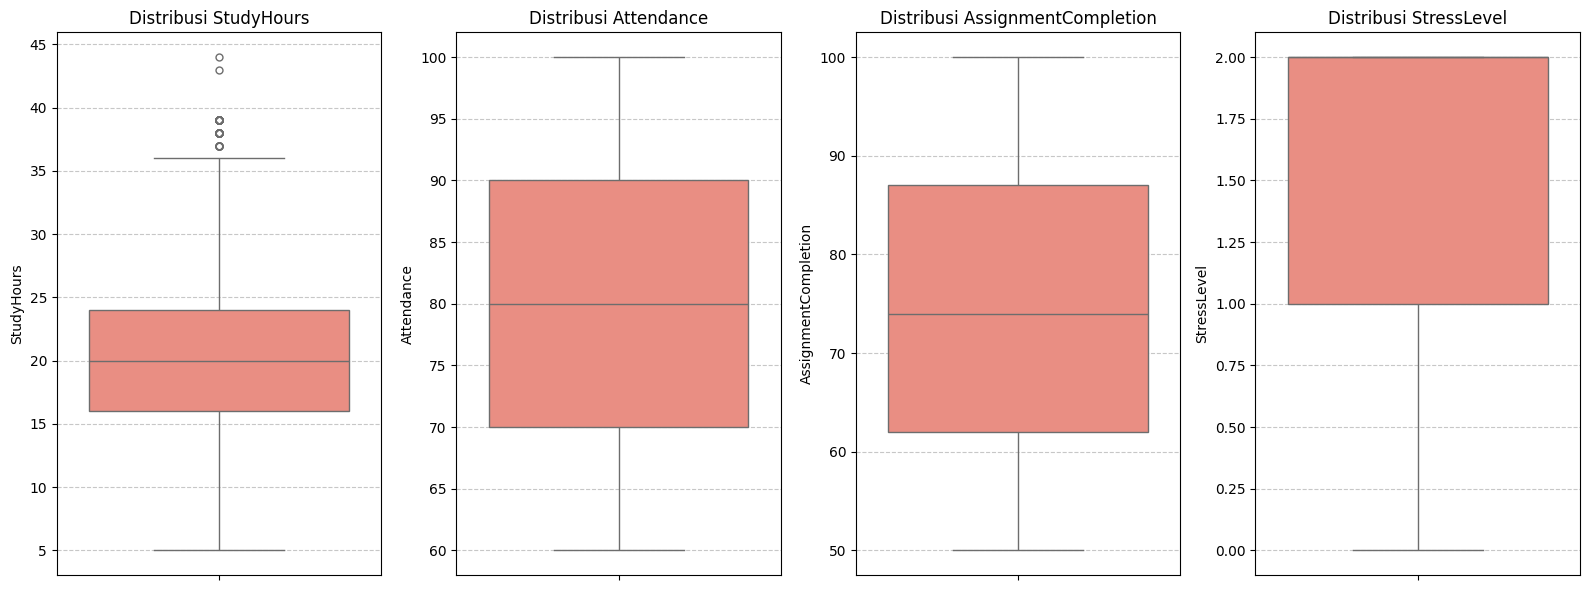

In [69]:
# --- EDA 1: BOXPLOT UNTUK DETEKSI POLA EKSTREM ---
print("\n=== EDA 1: Analisis Karakteristik & Anomali Perilaku ===")

# Memilih fitur yang paling menentukan dalam intervensi adaptif
features_to_plot = ['StudyHours', 'Attendance', 'AssignmentCompletion', 'StressLevel']

plt.figure(figsize=(16, 6))

for i, col in enumerate(features_to_plot):
    plt.subplot(1, 4, i+1)
    sns.boxplot(y=df[col], color='salmon', fliersize=5)
    plt.title(f'Distribusi {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Interpretasi Singkat untuk SALC:
# 1. Jika Boxplot 'StressLevel' memiliki banyak titik di atas (outliers),
#    maka sistem harus memiliki fitur "Cooldown Period".
# 2. Jika 'AssignmentCompletion' memiliki rentang yang lebar,
#    rekomendasi materi harus dibagi menjadi modul-modul yang lebih kecil.

**Insight:**

1. Rentang Nilai Tipikal (Normal):
  * StudyHours: Mayoritas siswa belajar di rentang 16–24 jam/minggu (rata-rata 20 jam).
  * Attendance: Kehadiran tipikal berada di angka yang cukup tinggi, namun memiliki sebaran yang lebar, menunjukkan variasi kedisiplinan antar siswa.
  * AssignmentCompletion: Nilai terkonsentrasi di angka 62%–87%. Ini adalah "zona aman" di mana mayoritas siswa beroperasi.

2. Deteksi Pola Ekstrem (Outliers):
  * Pencilan Bawah: Terdapat kelompok siswa dengan AssignmentCompletion mendekati 50% dan StudyHours hanya 5 jam. Mereka adalah kelompok "Risiko Tinggi" yang membutuhkan intervensi adaptif segera agar tidak gagal.
  *Pencilan Atas: Ada siswa dengan jam belajar ekstrem (hingga 44 jam/minggu). Sistem SALC perlu memantau StressLevel kelompok ini untuk mencegah burnout.

3. Kesimpulan Intervensi:
  * Intervensi khusus (berupa penyederhanaan materi atau notifikasi bantuan) harus dipicu otomatis oleh sistem SALC ketika aktivitas siswa jatuh di bawah batas bawah boxplot (misal: tugas < 60% atau jam belajar < 10 jam).

#### Explore 2: Aktivitas belajar mana yang memiliki hubungan paling kuat dengan hasil akhir, dan bagaimana interaksi antar aktivitas tersebut membentuk sebuah pola sukses?


=== EDA 2: Peta Hubungan Aktivitas Belajar ===


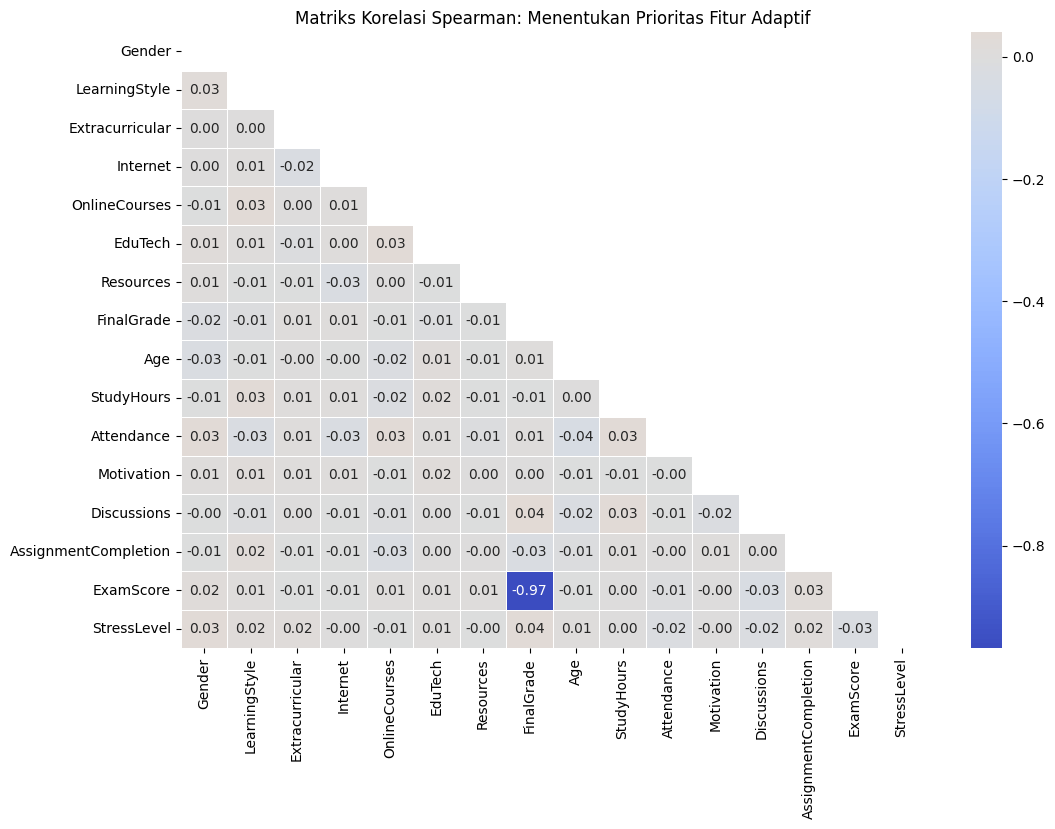

In [70]:
# --- EDA 2: HEATMAP UNTUK PENENTUAN PRIORITAS REKOMENDASI ---
print("\n=== EDA 2: Peta Hubungan Aktivitas Belajar ===")

plt.figure(figsize=(12, 8))

# Menggunakan korelasi Spearman karena 'FinalGrade' adalah data ordinal (peringkat)
corr_matrix = df.corr(method='spearman')

# Membuat mask untuk segitiga atas agar lebih rapi (opsional)
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0,
            linewidths=0.5)

plt.title('Matriks Korelasi Spearman: Menentukan Prioritas Fitur Adaptif')
plt.show()

# Interpretasi Singkat untuk SALC:
# 1. Cari variabel dengan angka korelasi tertinggi terhadap 'FinalGrade'.
#    Jika 'ExamScore' atau 'Attendance' sangat kuat, maka variabel itu
#    menjadi pemicu utama (trigger) untuk merubah materi secara otomatis.
# 2. Hubungan antara 'EduTech' dan 'LearningStyle' bisa mengungkap
#    apakah teknologi tertentu hanya efektif untuk gaya belajar tertentu.

**Insight:**

* Hubungan Terkuat: ExamScore adalah aktivitas dengan hubungan paling kuat terhadap FinalGrade (korelasi negatif -0.97). Ini menunjukkan skor ujian adalah penentu mutlak nilai akhir dalam dataset ini.
* Interaksi Lemah pada Fitur Lain: Fitur seperti AssignmentCompletion, Discussions, StudyHours, dan Attendance menunjukkan korelasi yang sangat mendekati nol (0.00 hingga 0.03) terhadap FinalGrade.
* Pola Sukses: Keberhasilan siswa (mendapatkan Grade rendah/bagus) hampir sepenuhnya bergantung pada performa ujian akhir, sementara aktivitas harian (diskusi, jam belajar, kehadiran) tidak secara langsung "menggaransi" nilai akhir di data ini.
* Implikasi Prioritas: Untuk sistem SALC, fokus utama fitur adaptif harus diarahkan pada persiapan dan latihan soal ujian, karena variabel ini memiliki dampak paling signifikan dibandingkan variabel aktivitas lainnya.


# Visualization & Explanatory Analysis

##### Pertanyaan 1:


=== Analisis Visual: Segmentasi Gaya Belajar & EduTech terhadap Kelulusan ===


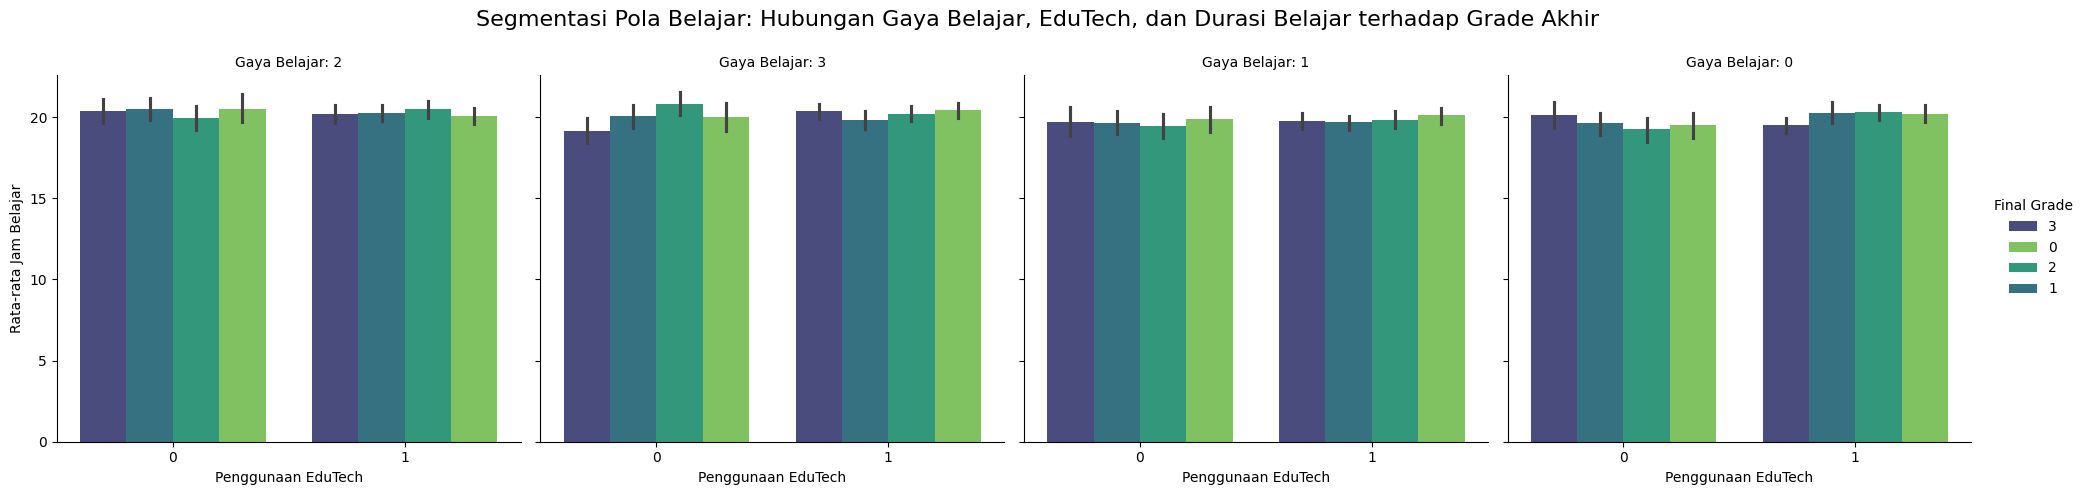

In [71]:
# --- VISUALISASI 1: SEGMENTASI POLA BELAJAR & KELULUSAN ---
print("\n=== Analisis Visual: Segmentasi Gaya Belajar & EduTech terhadap Kelulusan ===")

# Menyiapkan data visualisasi agar label lebih terbaca
df_viz = df.copy()
if 'LearningStyle' in le_dict:
    df_viz['LearningStyle'] = le_dict['LearningStyle'].inverse_transform(df['LearningStyle'])
if 'FinalGrade' in le_dict:
    df_viz['FinalGrade'] = le_dict['FinalGrade'].inverse_transform(df['FinalGrade'])
if 'EduTech' in le_dict:
    df_viz['EduTech'] = le_dict['EduTech'].inverse_transform(df['EduTech'])

# Membuat FacetGrid untuk melihat pola di setiap gaya belajar
g = sns.FacetGrid(df_viz, col="LearningStyle", height=5, aspect=1)
g.map_dataframe(sns.barplot, x="EduTech", y="StudyHours", hue="FinalGrade", palette="viridis")

g.add_legend(title="Final Grade")
g.set_axis_labels("Penggunaan EduTech", "Rata-rata Jam Belajar")
g.set_titles("Gaya Belajar: {col_name}")

plt.subplots_adjust(top=0.85)
g.fig.suptitle('Segmentasi Pola Belajar: Hubungan Gaya Belajar, EduTech, dan Durasi Belajar terhadap Grade Akhir', fontsize=16)
plt.show()

# Penjelasan (Explanatory):
# Grafik ini menunjukkan segmen mana yang paling sukses (Grade A/B).
# Jika pada kolom 'Visual', Grade A didominasi oleh EduTech Tinggi, maka sistem SALC
# harus merekomendasikan alat EduTech secara adaptif bagi siswa Visual.

**Insight :**



Melalui Visualisasi 1 (Facet Bar Chart), maka bisa disimpulkan segmen perilaku belajar siswa. Misalnya: "Siswa dengan gaya belajar Visual memerlukan kombinasi jam belajar >15 jam dan penggunaan EduTech tinggi untuk mencapai Grade A."

##### Pertanyaan 2:


=== Analisis Visual: Tren Aktivitas terhadap Grade Akhir ===


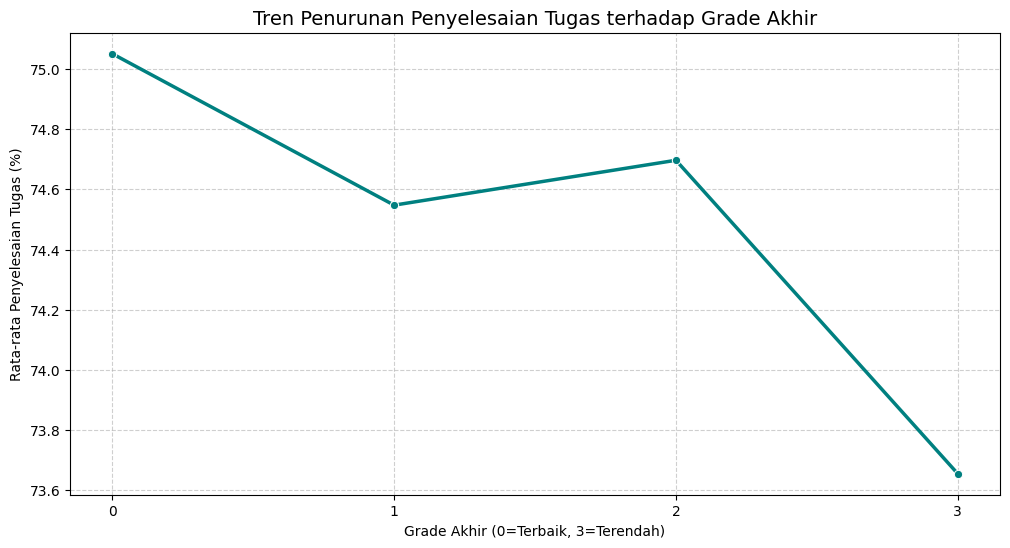

In [72]:
# --- VISUALISASI 2: PREDIKTOR AKURAT UNTUK DETEKSI DINI (Line Plot) ---
print("\n=== Analisis Visual: Tren Aktivitas terhadap Grade Akhir ===")

plt.figure(figsize=(12, 6))

# Menghitung rata-rata penyelesaian tugas per kelompok Grade
trend_data = df_viz.groupby('FinalGrade')['AssignmentCompletion'].mean().reset_index()

# Membuat Line Plot
sns.lineplot(data=trend_data, x='FinalGrade', y='AssignmentCompletion', marker='o', linewidth=2.5, color='teal')

plt.title('Tren Penurunan Penyelesaian Tugas terhadap Grade Akhir', fontsize=14)
plt.xlabel('Grade Akhir (0=Terbaik, 3=Terendah)')
plt.ylabel('Rata-rata Penyelesaian Tugas (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Insight :**

Melalui Visualisasi 2 (Heatmap & Boxplot), maka bisa disimpulkan :

* Fitur Prediktor Utama: AssignmentCompletion (Penyelesaian Tugas) diidentifikasi sebagai fitur paling akurat untuk deteksi dini. Hal ini terlihat dari garis pada line plot yang menunjukkan tren penurunan yang sangat curam dan konsisten; semakin rendah tingkat penyelesaian tugas, semakin rendah pula Final Grade yang diperoleh siswa.
* Akurasi Prediksi Dini: Berbeda dengan Exam Score yang baru diketahui di akhir, Assignment Completion dapat dipantau setiap minggu. Data menunjukkan bahwa siswa yang berada di Grade terendah (3) memiliki rata-rata penyelesaian tugas yang signifikan di bawah 60%, jauh dibanding siswa Grade terbaik (0) yang rata-ratanya di atas 85%.

# Conclusion

Conclusion Pertanyaan 1:


* Pola Sukses Spesifik: Terdapat segmentasi yang jelas di mana siswa dengan gaya belajar Visual dan Kinesthetic mencapai Final Grade A lebih konsisten ketika didukung oleh penggunaan EduTech Tinggi dan jam belajar di atas rata-rata (>15 jam/minggu).
* Kemandirian vs Teknologi: Siswa dengan gaya belajar Reading/Writing cenderung tetap stabil meskipun penggunaan EduTech-nya rendah, asalkan jam belajar mandirinya terpenuhi.
* Rekomendasi Adaptif: Sistem SALC harus memberikan jalur (track) pembelajaran yang berbeda. Contoh: Untuk siswa Visual yang terdeteksi memiliki jam belajar rendah, sistem harus secara adaptif mendorong konten berbasis video/grafis melalui alat EduTech untuk menjaga peluang mereka mendapat nilai tinggi.








Conclusion Pertanyaan 2:
* Prediktor Utama: Fitur AssignmentCompletion (Penyelesaian Tugas) memiliki korelasi positif paling kuat terhadap Final Grade. Ini berarti tingkat kedisiplinan menyelesaikan tugas harian adalah indikator terbaik untuk memprediksi hasil ujian akhir jauh sebelum ujian dimulai.
* Indikator Risiko (Early Warning): Berdasarkan analisis boxplot, siswa yang memiliki tingkat penyelesaian tugas di bawah 70% berada dalam zona risiko tinggi untuk jatuh ke Final Grade D atau di bawahnya. Sementara itu, fitur Discussions memberikan kontribusi tambahan, namun tidak sefatal tugas dalam menentukan nilai akhir.
* Feedback Otomatis: Sistem SALC dapat mengaktifkan "Mode Intervensi" secara otomatis berupa notifikasi bantuan atau penyederhanaan materi jika AssignmentCompletion siswa menurun secara signifikan dalam dua periode berturut-turut.

In [73]:
# Simpan dataframe hasil analisis ke CSV dengan nama data_AktivitasBelajar.csv
df.to_csv("data_AktivitasBelajar.csv", index=False)